In [23]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import xgboost as xgb
from hmmlearn import hmm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [24]:
tickers = [
    "SPY",   
    "QQQ",   
    "IWM",   
    "TLT",   
    "GLD",   
    "NVDA",  
    "JPM",   
    "XOM",   
    "JNJ",   
    "VNQ"    
]

# List để chứa dữ liệu tạm
all_data = []

for ticker in tickers:

    df = yf.Ticker(ticker).history(period="max", auto_adjust=True)
    df.drop(["Dividends", "Stock Splits"], axis=1, inplace=True)

    df = df.loc["1990-01-01":].copy()
    
    if len(df) > 0:
        # Định danh mã cổ phiếu
        df['Symbol'] = ticker 
        
        # Reset index để đưa Date vào làm một cột
        df = df.reset_index()
        
        df['Returns'] = df['Close'].pct_change()
        
        df = df.dropna()
        
        all_data.append(df)

# 2. Gộp tất cả lại thành một bảng dài (Long Format)
final_df = pd.concat(all_data, ignore_index=True)

# Sắp xếp lại cho đẹp: Theo Mã -> Theo Ngày
final_df = final_df.sort_values(by=['Symbol', 'Date'])

final_df

,Date,Open,High,Low,Close,Volume,Capital Gains,Symbol,Returns
27439,2004-11-19 00:00:00-05:00,44.490002,44.919998,44.470001,44.779999,11655300,0.0,GLD,0.009013
27440,2004-11-22 00:00:00-05:00,44.750000,44.970001,44.740002,44.950001,11996000,0.0,GLD,0.003796
27441,2004-11-23 00:00:00-05:00,44.880001,44.919998,44.720001,44.750000,3169200,0.0,GLD,-0.004449
27442,2004-11-24 00:00:00-05:00,44.930000,45.049999,44.790001,45.049999,6105100,0.0,GLD,0.006704
27443,2004-11-26 00:00:00-05:00,45.250000,45.599998,45.060001,45.290001,3097700,0.0,GLD,0.005327
...,...,...,...,...,...,...,...,...,...
57731,2026-01-23 00:00:00-05:00,135.089996,135.979996,134.479996,134.970001,17758200,NaN,XOM,0.009952
57732,2026-01-26 00:00:00-05:00,136.929993,136.940002,134.169998,134.839996,16056100,NaN,XOM,-0.000963
57733,2026-01-27 00:00:00-05:00,135.250000,136.929993,134.710007,136.830002,14517000,NaN,XOM,0.014758
57734,2026-01-28 00:00:00-05:00,137.690002,138.009995,136.669998,137.580002,15637300,NaN,XOM,0.005481


## Step 1: Hidden Markov Model - Regime Detection

In [25]:
split_date = '2016-01-01'

train_mask = final_df['Date'] < split_date
test_mask = final_df['Date'] >= split_date

train_data = final_df[train_mask].copy()
test_data = final_df[test_mask].copy()

print(f"Train period: {train_data['Date'].min()} to {train_data['Date'].max()} ({len(train_data)} samples)")
print(f"Test period: {test_data['Date'].min()} to {test_data['Date'].max()} ({len(test_data)} samples)")

print("\n" + "="*60)
print("STANDARDIZING RETURNS BY TICKER (Z-SCORE)")
print("="*60)

# Standardize returns for each ticker separately
for ticker in tickers:
    # Train data
    ticker_train_mask = train_data['Symbol'] == ticker
    train_returns = train_data.loc[ticker_train_mask, 'Returns']
    train_mean = train_returns.mean()
    train_std = train_returns.std()
    
    print(f"{ticker} - Train: mean={train_mean:.6f}, std={train_std:.6f}")
    
    # Standardize train
    train_data.loc[ticker_train_mask, 'Returns_Standardized'] = (train_returns - train_mean) / train_std
    
    # Standardize test using TRAIN 
    ticker_test_mask = test_data['Symbol'] == ticker
    test_returns = test_data.loc[ticker_test_mask, 'Returns']
    test_data.loc[ticker_test_mask, 'Returns_Standardized'] = (test_returns - train_mean) / train_std

print("\n" + "="*60)
print("FITTING HMM ON STANDARDIZED RETURNS")
print("="*60)

# Use standardized returns for HMM
returns_train = train_data['Returns_Standardized'].values.reshape(-1, 1)

n_regimes = 3
model_hmm = hmm.GaussianHMM(
    n_components=n_regimes,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

print("\nFitting HMM on TRAIN data (standardized returns, all 6 tickers)...")
model_hmm.fit(returns_train)

train_data['Regime'] = model_hmm.predict(returns_train)
train_regime_probs = model_hmm.predict_proba(returns_train)
for i in range(n_regimes):
    train_data[f'Regime_Prob_{i}'] = train_regime_probs[:, i]

returns_test = test_data['Returns_Standardized'].values.reshape(-1, 1)
test_data['Regime'] = model_hmm.predict(returns_test)
test_regime_probs = model_hmm.predict_proba(returns_test)
for i in range(n_regimes):
    test_data[f'Regime_Prob_{i}'] = test_regime_probs[:, i]

combined_data = pd.concat([train_data, test_data])

print("\n" + "="*60)
print("REGIME CHARACTERISTICS (TRAIN - STANDARDIZED RETURNS)")
print("="*60)
for i in range(n_regimes):
    regime_returns = train_data[train_data['Regime'] == i]['Returns_Standardized']
    print(f"\nRegime {i}:")
    print(f"  Mean Standardized Return: {regime_returns.mean():.4f}")
    print(f"  Std Standardized Return: {regime_returns.std():.4f}")
    print(f"  Count: {len(regime_returns)} days ({len(regime_returns)/len(train_data)*100:.1f}%)")

# Check regime distribution by ticker
print("\n" + "="*60)
print("REGIME DISTRIBUTION BY TICKER (TRAIN)")
print("="*60)
for ticker in tickers:
    ticker_data = train_data[train_data['Symbol'] == ticker]
    regime_dist = ticker_data['Regime'].value_counts(normalize=True).sort_index() * 100
    print(f"\n{ticker}:")
    for regime_id in range(n_regimes):
        pct = regime_dist.get(regime_id, 0)
        print(f"  Regime {regime_id}: {pct:.1f}%")

print("\n" + "="*60)
print("TRANSITION MATRIX")
print("="*60)
print(pd.DataFrame(model_hmm.transmat_,
                   columns=[f'To Regime {i}' for i in range(n_regimes)],
                   index=[f'From Regime {i}' for i in range(n_regimes)]))

print("\n" + "="*60)
print("REGIME DISTRIBUTION IN TEST DATA")
print("="*60)
for i in range(n_regimes):
    test_regime_count = (test_data['Regime'] == i).sum()
    print(f"Regime {i}: {test_regime_count} days ({test_regime_count/len(test_data)*100:.1f}%)")

combined_data[['Date', 'Symbol', 'Returns', 'Returns_Standardized', 'Regime', 'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2']].head(10)

Train period: 1990-01-03 00:00:00-05:00 to 2015-12-31 00:00:00-05:00 (46858 samples)
Test period: 2016-01-04 00:00:00-05:00 to 2026-01-29 00:00:00-05:00 (25330 samples)

STANDARDIZING RETURNS BY TICKER (Z-SCORE)
SPY - Train: mean=0.000411, std=0.011905
QQQ - Train: mean=0.000380, std=0.018571
IWM - Train: mean=0.000402, std=0.015456
TLT - Train: mean=0.000311, std=0.008763
GLD - Train: mean=0.000374, std=0.012515
NVDA - Train: mean=0.001542, std=0.040739
JPM - Train: mean=0.000725, std=0.024801
XOM - Train: mean=0.000507, std=0.014824
JNJ - Train: mean=0.000582, std=0.013742
VNQ - Train: mean=0.000581, std=0.021472

FITTING HMM ON STANDARDIZED RETURNS

Fitting HMM on TRAIN data (standardized returns, all 6 tickers)...

REGIME CHARACTERISTICS (TRAIN - STANDARDIZED RETURNS)

Regime 0:
  Mean Standardized Return: -0.0203
  Std Standardized Return: 2.2686
  Count: 3821 days (8.2%)

Regime 1:
  Mean Standardized Return: -0.0089
  Std Standardized Return: 0.9682
  Count: 23936 days (51.1%)



,Date,Symbol,Returns,Returns_Standardized,Regime,Regime_Prob_0,Regime_Prob_1,Regime_Prob_2
27439,2004-11-19 00:00:00-05:00,GLD,0.009013,0.690320,2,3.643184e-161,3.375610e-102,1.000000
27440,2004-11-22 00:00:00-05:00,GLD,0.003796,0.273473,2,5.305471e-08,1.060202e-02,0.989398
27441,2004-11-23 00:00:00-05:00,GLD,-0.004449,-0.385423,2,3.313212e-06,2.931145e-02,0.970685
27442,2004-11-24 00:00:00-05:00,GLD,0.006704,0.505804,2,1.102456e-05,5.722379e-02,0.942765
27443,2004-11-26 00:00:00-05:00,GLD,0.005327,0.395817,2,2.314020e-05,9.597986e-02,0.903997
27444,2004-11-29 00:00:00-05:00,GLD,0.002429,0.164194,2,4.240255e-05,1.582969e-01,0.841661
27445,2004-11-30 00:00:00-05:00,GLD,-0.006167,-0.522708,2,8.480901e-05,2.779609e-01,0.721954
27446,2004-12-01 00:00:00-05:00,GLD,0.005762,0.430577,2,1.762294e-04,4.247359e-01,0.575088
27447,2004-12-02 00:00:00-05:00,GLD,-0.009476,-0.787048,2,3.798374e-04,6.514240e-01,0.348196
27448,2004-12-03 00:00:00-05:00,GLD,0.014460,1.125609,2,7.586140e-04,8.105393e-01,0.188702


Plotting regimes for all tickers...


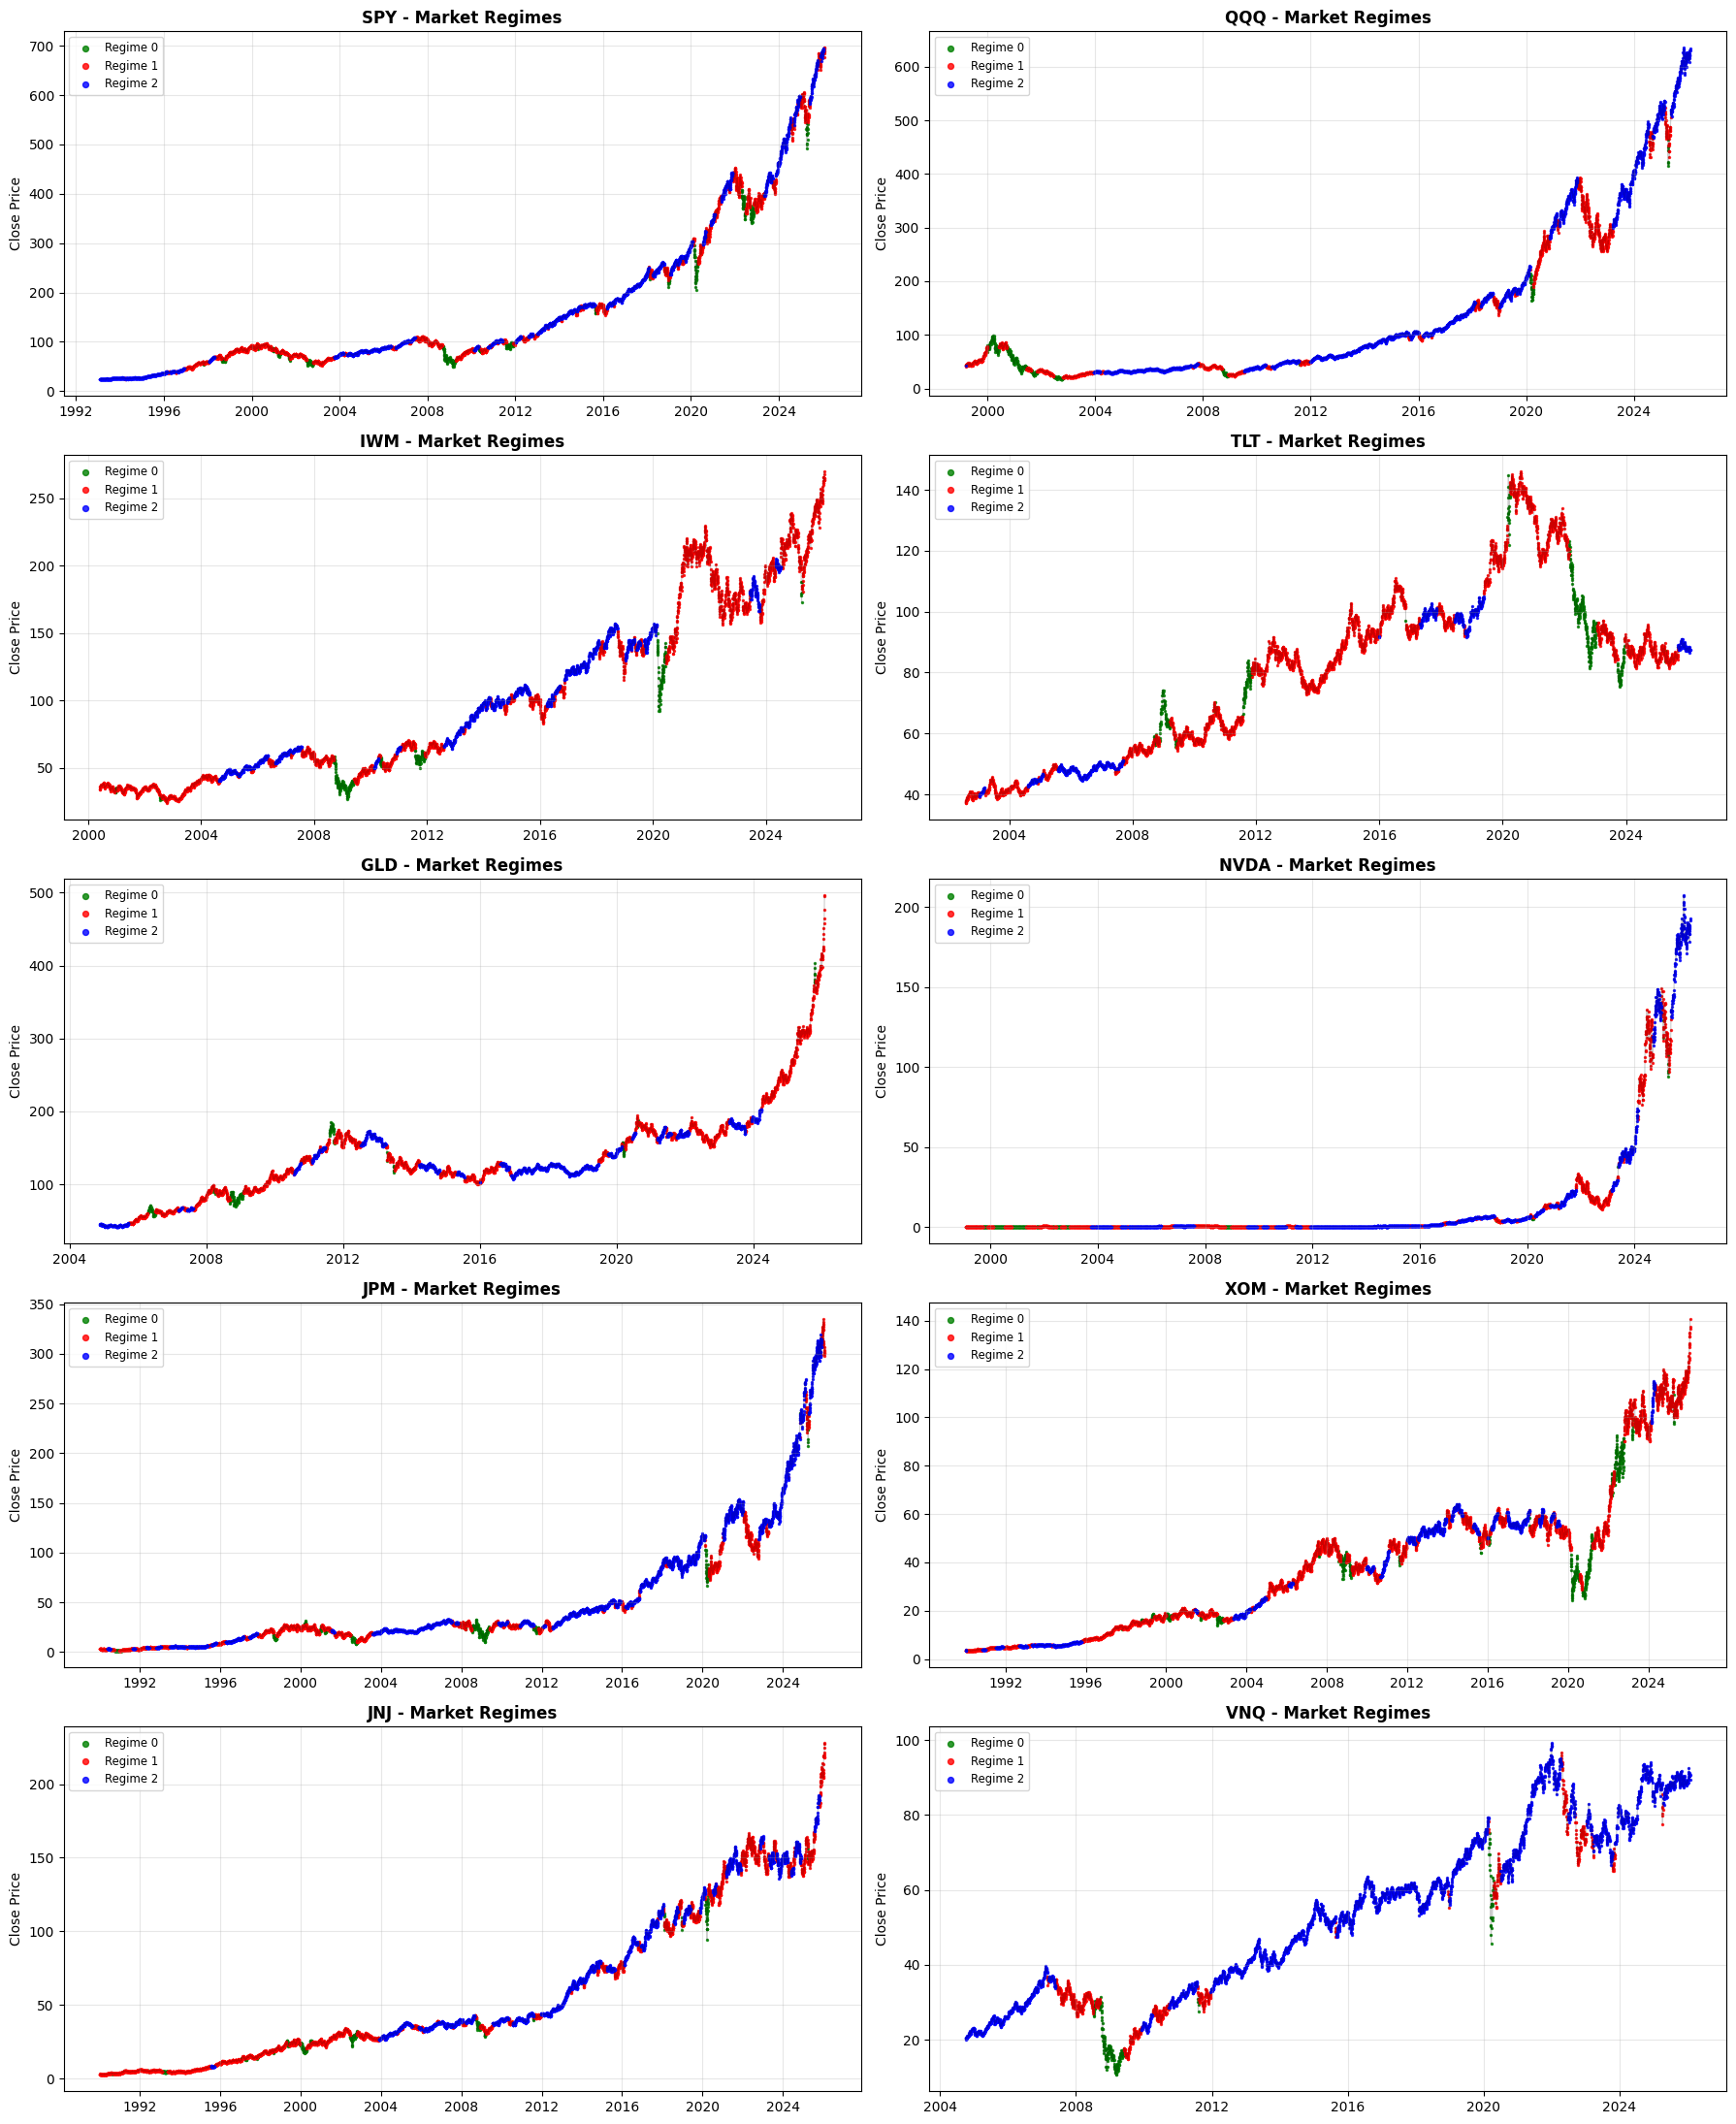

In [26]:
import matplotlib.pyplot as plt


tickers = [
    "SPY",   
    "QQQ",   
    "IWM",   
    "TLT",   
    "GLD",   
    "NVDA",  
    "JPM",   
    "XOM",   
    "JNJ",   
    "VNQ"    
]

fig, axes = plt.subplots(5, 2, figsize=(18, 22)) 
axes = axes.flatten() 

colors = ['green', 'red', 'blue']
regime_names = ['Regime 0', 'Regime 1', 'Regime 2']

print("Plotting regimes for all tickers...")

for idx, ticker in enumerate(tickers):
    if ticker not in combined_data['Symbol'].unique():
        print(f"Warning: {ticker} not found in combined_data. Skipping...")
        axes[idx].set_title(f'{ticker} - No Data Available')
        continue

    ax = axes[idx]
    
    ticker_data = combined_data[combined_data['Symbol'] == ticker].copy()
    ticker_data = ticker_data.set_index('Date')
    
    # Vẽ đường giá mờ làm nền
    ax.plot(ticker_data.index, ticker_data['Close'], linewidth=0.8, color='black', alpha=0.2)
    
    # Vẽ các điểm Regime
    for i in range(n_regimes):
        mask = ticker_data['Regime'] == i
        if mask.sum() > 0: # Chỉ vẽ nếu có dữ liệu của regime đó
            ax.scatter(ticker_data.index[mask], ticker_data['Close'][mask],
                       c=colors[i], s=2, alpha=0.8, label=regime_names[i])
    
    ax.set_ylabel('Close Price')
    ax.set_title(f'{ticker} - Market Regimes', fontweight='bold')
    ax.legend(loc='upper left', fontsize='small', markerscale=3)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: Feature Engineering - Technical Indicators

In [27]:
df = combined_data.copy()
df = df.sort_values(['Symbol', 'Date'])

print("\nNaN count by column:")
print(df.isnull().sum())
print("\nNaN in Capital Gains by ticker:")
for ticker in tickers:
    ticker_df = df[df['Symbol'] == ticker]
    nan_count = ticker_df['Capital Gains'].isnull().sum()
    print(f"  {ticker}: {nan_count}/{len(ticker_df)} NaN ({nan_count/len(ticker_df)*100:.1f}%)")

print("\n" + "="*60)
print("DROPPING 'Capital Gains' COLUMN")
print("="*60)
df = df.drop('Capital Gains', axis=1)

print("="*60)
print("BƯỚC 1: DỮ LIỆU SAU KHI HMM (BEFORE FEATURE ENGINEERING)")
print("="*60)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

all_ticker_dfs = []
for ticker in tickers:
    ticker_df = df[df['Symbol'] == ticker].copy()
    ticker_df = ticker_df.set_index('Date')
    
    # Trend Indicators
    ticker_df['SMA_10'] = ta.sma(ticker_df['Close'], length=10)
    ticker_df['SMA_50'] = ta.sma(ticker_df['Close'], length=50)
    ticker_df['EMA_12'] = ta.ema(ticker_df['Close'], length=12)
    ticker_df['EMA_26'] = ta.ema(ticker_df['Close'], length=26)
    
    # Momentum Indicators
    ticker_df['RSI'] = ta.rsi(ticker_df['Close'], length=14)
    macd = ta.macd(ticker_df['Close'])
    ticker_df['MACD'] = macd['MACD_12_26_9']
    ticker_df['MACD_signal'] = macd['MACDs_12_26_9']
    ticker_df['MACD_hist'] = macd['MACDh_12_26_9']
    
    # Volatility Indicators
    bbands = ta.bbands(ticker_df['Close'], length=20)
    if bbands is not None:
        bb_cols = bbands.columns.tolist()
        ticker_df['BB_upper'] = bbands[bb_cols[0]]
        ticker_df['BB_middle'] = bbands[bb_cols[1]]
        ticker_df['BB_lower'] = bbands[bb_cols[2]]
        ticker_df['BB_width'] = (ticker_df['BB_upper'] - ticker_df['BB_lower']) / ticker_df['BB_middle']
    
    ticker_df['ATR'] = ta.atr(ticker_df['High'], ticker_df['Low'], ticker_df['Close'], length=14)
    
    # Volume Indicators
    ticker_df['Volume_SMA'] = ta.sma(ticker_df['Volume'], length=20)
    ticker_df['Volume_ratio'] = ticker_df['Volume'] / ticker_df['Volume_SMA']
    
    # Price-based features
    ticker_df['Price_change_1d'] = ticker_df['Close'].pct_change(1)
    ticker_df['Price_change_5d'] = ticker_df['Close'].pct_change(5)
    ticker_df['Price_change_20d'] = ticker_df['Close'].pct_change(20)
    ticker_df['Volatility_20d'] = ticker_df['Returns'].rolling(window=20).std()
    
    # Distance from moving averages
    ticker_df['Dist_SMA10'] = (ticker_df['Close'] - ticker_df['SMA_10']) / ticker_df['SMA_10']
    ticker_df['Dist_SMA50'] = (ticker_df['Close'] - ticker_df['SMA_50']) / ticker_df['SMA_50']
    ticker_df['Dist_EMA12'] = (ticker_df['Close'] - ticker_df['EMA_12']) / ticker_df['EMA_12']
    
    # Position within Bollinger Bands
    ticker_df['BB_position'] = (ticker_df['Close'] - ticker_df['BB_lower']) / (ticker_df['BB_upper'] - ticker_df['BB_lower'])
    
    # Lag features
    for lag in [1, 2, 3, 5]:
        ticker_df[f'Return_lag_{lag}'] = ticker_df['Returns'].shift(lag)
    
    ticker_df = ticker_df.reset_index()
    
    print(f"\n{ticker} - BEFORE dropna: {len(ticker_df)} rows")
    ticker_df = ticker_df.dropna()
    print(f"{ticker} - AFTER dropna: {len(ticker_df)} rows (lost {len(df[df['Symbol'] == ticker]) - len(ticker_df)} rows)")
    
    all_ticker_dfs.append(ticker_df)

df = pd.concat(all_ticker_dfs, ignore_index=True)

print("\n" + "="*60)
print("BƯỚC 2: SAU KHI TÍNH FEATURES VÀ DROPNA")
print("="*60)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

print(f"\nFeatures created: {df.shape[1]} columns")
print(f"Data points: {df.shape[0]} rows")
print(f"\nFeature columns:")
print([col for col in df.columns if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol']])


NaN count by column:
Date                        0
Open                        0
High                        0
Low                         0
Close                       0
Volume                      0
Capital Gains           34051
Symbol                      0
Returns                     0
Returns_Standardized        0
Regime                      0
Regime_Prob_0               0
Regime_Prob_1               0
Regime_Prob_2               0
dtype: int64

NaN in Capital Gains by ticker:
  SPY: 0/8306 NaN (0.0%)
  QQQ: 0/6764 NaN (0.0%)
  IWM: 0/6456 NaN (0.0%)
  TLT: 0/5913 NaN (0.0%)
  GLD: 0/5331 NaN (0.0%)
  NVDA: 6796/6796 NaN (100.0%)
  JPM: 9085/9085 NaN (100.0%)
  XOM: 9085/9085 NaN (100.0%)
  JNJ: 9085/9085 NaN (100.0%)
  VNQ: 0/5367 NaN (0.0%)

DROPPING 'Capital Gains' COLUMN
BƯỚC 1: DỮ LIỆU SAU KHI HMM (BEFORE FEATURE ENGINEERING)
Total rows: 72188
  SPY: 8306 rows
  QQQ: 6764 rows
  IWM: 6456 rows
  TLT: 5913 rows
  GLD: 5331 rows
  NVDA: 6796 rows
  JPM: 9085 rows
  XOM: 9085 r

## Step 3: Create Target Variable (10-Day Prediction)


In [28]:
print("="*60)
print("TARGET (10-DAY FORWARD)")
print("="*60)
print(f"Before creating target: {len(df)} rows")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

df = df.sort_values(['Symbol', 'Date'])

all_target_dfs = []
for ticker in tickers:
    ticker_df = df[df['Symbol'] == ticker].copy()
    
    print(f"\n{ticker}:")
    print(f"  Before shift: {len(ticker_df)} rows")
    
    ticker_df['Return_10d_forward'] = ticker_df['Close'].pct_change(10).shift(-10)
    ticker_df['Target'] = (ticker_df['Return_10d_forward'] > 0).astype(int)
    
    print(f"  After shift (before removing last 10): {len(ticker_df)} rows")
    
    ticker_df = ticker_df[:-10]
    
    print(f"  After removing last 10 rows: {len(ticker_df)} rows")
    
    all_target_dfs.append(ticker_df)

df = pd.concat(all_target_dfs, ignore_index=True)

print("\n" + "="*60)
print("TARGET DISTRIBUTION (10-DAY PREDICTION - ALL TICKERS)")
print("="*60)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

print(f"\n{df['Target'].value_counts()}")
print(f"\nClass 1 (Up): {df['Target'].sum()} periods ({df['Target'].mean()*100:.2f}%)")
print(f"Class 0 (Down): {(1-df['Target']).sum()} periods ({(1-df['Target'].mean())*100:.2f}%)")

print("\n" + "="*60)
print("10-DAY TARGET DISTRIBUTION BY REGIME")
print("="*60)
for i in range(n_regimes):
    regime_data = df[df['Regime'] == i]
    up_pct = regime_data['Target'].mean() * 100
    print(f"Regime {i}: {up_pct:.2f}% up periods (10-day forward)")

TARGET (10-DAY FORWARD)
Before creating target: 71698 rows
  SPY: 8257 rows
  QQQ: 6715 rows
  IWM: 6407 rows
  TLT: 5864 rows
  GLD: 5282 rows
  NVDA: 6747 rows
  JPM: 9036 rows
  XOM: 9036 rows
  JNJ: 9036 rows
  VNQ: 5318 rows

SPY:
  Before shift: 8257 rows
  After shift (before removing last 10): 8257 rows
  After removing last 10 rows: 8247 rows

QQQ:
  Before shift: 6715 rows
  After shift (before removing last 10): 6715 rows
  After removing last 10 rows: 6705 rows

IWM:
  Before shift: 6407 rows
  After shift (before removing last 10): 6407 rows
  After removing last 10 rows: 6397 rows

TLT:
  Before shift: 5864 rows
  After shift (before removing last 10): 5864 rows
  After removing last 10 rows: 5854 rows

GLD:
  Before shift: 5282 rows
  After shift (before removing last 10): 5282 rows
  After removing last 10 rows: 5272 rows

NVDA:
  Before shift: 6747 rows
  After shift (before removing last 10): 6747 rows
  After removing last 10 rows: 6737 rows

JPM:
  Before shift: 903

## Step 4: Prepare Training Data with Regime Features

In [29]:
feature_columns = [
    # Momentum
    'RSI', 'MACD', 'MACD_hist',
    # Volatility
    'BB_width', 'ATR', 'Volatility_20d',
    # Volume
    # 'Volume_ratio',
    # Price changes
    # 'Price_change_5d', 
    'Price_change_20d',
    # Distance from moving averages (NEW)
    'Dist_SMA10', 'Dist_SMA50', 
    # 'Dist_EMA12',
    # Bollinger Band position (NEW)
    # 'BB_position',
    # Regime features
    'Regime', 'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2'
]

X = df[feature_columns].copy()
y = df['Target'].copy()
dates = df['Date'].copy()

print("="*60)
print("FEATURE MATRIX (ALL 6 TICKERS)")
print("="*60)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures used ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

split_date = '2016-01-01'
train_mask = df['Date'] < split_date
test_mask = df['Date'] >= split_date

X_train, X_test = X[train_mask].reset_index(drop=True), X[test_mask].reset_index(drop=True)
y_train, y_test = y[train_mask].reset_index(drop=True), y[test_mask].reset_index(drop=True)
train_dates = dates[train_mask].reset_index(drop=True)
test_dates = dates[test_mask].reset_index(drop=True)
train_symbols = df[train_mask]['Symbol'].reset_index(drop=True)
test_symbols = df[test_mask]['Symbol'].reset_index(drop=True)

print("\n" + "="*60)
print("TRAIN/TEST SPLIT (ALL 6 TICKERS COMBINED)")
print("="*60)
print(f"Train: {train_dates.min()} to {train_dates.max()} ({len(X_train)} samples)")
print(f"Test: {test_dates.min()} to {test_dates.max()} ({len(X_test)} samples)")
print(f"\nTrain positive class: {y_train.mean()*100:.2f}%")
print(f"Test positive class: {y_test.mean()*100:.2f}%")

FEATURE MATRIX (ALL 6 TICKERS)
X shape: (71598, 13)
y shape: (71598,)

Features used (13):
   1. RSI
   2. MACD
   3. MACD_hist
   4. BB_width
   5. ATR
   6. Volatility_20d
   7. Price_change_20d
   8. Dist_SMA10
   9. Dist_SMA50
  10. Regime
  11. Regime_Prob_0
  12. Regime_Prob_1
  13. Regime_Prob_2

TRAIN/TEST SPLIT (ALL 6 TICKERS COMBINED)
Train: 1990-03-14 00:00:00-05:00 to 2015-12-31 00:00:00-05:00 (46368 samples)
Test: 2016-01-04 00:00:00-05:00 to 2026-01-14 00:00:00-05:00 (25230 samples)

Train positive class: 56.42%
Test positive class: 58.81%


## Step 5: Train XGBoost Classifier

In [30]:
print("="*60)
print("BƯỚC 1: TÍNH TOÁN TRỌNG SỐ MẪU (SAMPLE WEIGHTS)")
print("="*60)

# 1. Tính toán trọng số để cân bằng (Balanced)
weights_train = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

print(f"Trọng số cho Class DOWN (0): {weights_train[y_train == 0][0]:.4f}")
print(f"Trọng số cho Class UP (1):   {weights_train[y_train == 1][0]:.4f}")

print("\n" + "="*60)
print("BƯỚC 2: TRAIN XGBOOST - HIGH PERFORMANCE MODE")
print("="*60)

# 2. Cấu hình Model "Nới lỏng" để tăng khả năng học (Capacity)
model = xgb.XGBClassifier(
    n_estimators=3000,      
    learning_rate=0.02,     
    max_depth=8,            
    min_child_weight=10,    
    
    gamma=0.2,              
    subsample=0.85,         
    colsample_bytree=0.8,   
    
    reg_alpha=1.0,          
    reg_lambda=1.0,         
    
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    early_stopping_rounds=100
)

eval_set = [(X_train, y_train), (X_test, y_test)]

print("Training XGBoost...")
model.fit(
    X_train, y_train,
    sample_weight=weights_train,  
    eval_set=eval_set,
    verbose=False
)

print("Training completed!")

# 3. Xác suất dự báo 
y_pred_proba_train = model.predict_proba(X_train)[:, 1]
y_pred_proba_test = model.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("BƯỚC 3: TÌM NGƯỠNG TỐI ƯU CHO ACCURACY (THRESHOLD MOVING)")
print("="*60)

# Tự động tìm ngưỡng tối ưu Accuracy
thresholds = np.arange(0.5, 0.75, 0.001)
scores = []

for t in thresholds:
    y_temp = (y_pred_proba_test > t).astype(int)
    # THAY ĐỔI QUAN TRỌNG: Dùng Accuracy thay vì F1
    score = accuracy_score(y_test, y_temp)
    scores.append(score)

best_threshold = thresholds[np.argmax(scores)]
max_acc = max(scores)

print(f"Ngưỡng mặc định (0.50): Accuracy = {accuracy_score(y_test, (y_pred_proba_test > 0.5).astype(int)):.4f}")
print(f"Ngưỡng tối ưu ({best_threshold:.3f}): Accuracy = {max_acc:.4f}")

# Tạo dự đoán cuối cùng dựa trên ngưỡng tối ưu
y_pred_test_new = (y_pred_proba_test > best_threshold).astype(int)
y_pred_train_new = (y_pred_proba_train > best_threshold).astype(int)

print("\n" + "="*60)
print(f"MODEL PERFORMANCE (THRESHOLD = {best_threshold:.3f})")
print("="*60)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train_new):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_test_new):.4f}")

# Tính Gap để kiểm tra Overfitting
gap = accuracy_score(y_train, y_pred_train_new) - accuracy_score(y_test, y_pred_test_new)
print(f"Gap (Train - Test): {gap*100:.2f}%")

print("\n" + "-"*60)
print("TEST SET CLASSIFICATION REPORT")
print("-"*60)
print(classification_report(y_test, y_pred_test_new, target_names=['Down', 'Up']))

print("\n" + "="*60)
print("PER-TICKER TEST PERFORMANCE")
print("="*60)

ticker_results = []
for ticker in tickers:
    ticker_mask = test_symbols == ticker
    if ticker_mask.sum() > 0:
        y_true_ticker = y_test[ticker_mask]
        y_pred_ticker = y_pred_test_new[ticker_mask] # Dùng pred mới
        
        acc = accuracy_score(y_true_ticker, y_pred_ticker)
        prec = precision_score(y_true_ticker, y_pred_ticker, average='weighted', zero_division=0)
        rec = recall_score(y_true_ticker, y_pred_ticker, average='weighted', zero_division=0)
        f1 = f1_score(y_true_ticker, y_pred_ticker, average='weighted', zero_division=0)
        
        # Tính riêng Recall cho class Down (quan trọng để tránh lỗ)
        try:
            down_recall = recall_score(y_true_ticker, y_pred_ticker, pos_label=0, zero_division=0)
        except:
            down_recall = 0
            
        ticker_results.append({
            'Ticker': ticker,
            'Samples': ticker_mask.sum(),
            'Accuracy': acc,
            'Precision': prec,
            'Down Recall': down_recall 
        })

ticker_perf_df = pd.DataFrame(ticker_results)
# Sắp xếp theo Accuracy để dễ nhìn
ticker_perf_df = ticker_perf_df.sort_values(by='Accuracy', ascending=False)
print(ticker_perf_df.to_string(index=False))

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Best Accuracy: {ticker_perf_df.iloc[0]['Ticker']} ({ticker_perf_df.iloc[0]['Accuracy']:.4f})")

BƯỚC 1: TÍNH TOÁN TRỌNG SỐ MẪU (SAMPLE WEIGHTS)
Trọng số cho Class DOWN (0): 1.1474
Trọng số cho Class UP (1):   0.8861

BƯỚC 2: TRAIN XGBOOST - HIGH PERFORMANCE MODE
Training XGBoost...
Training completed!

BƯỚC 3: TÌM NGƯỠNG TỐI ƯU CHO ACCURACY (THRESHOLD MOVING)
Ngưỡng mặc định (0.50): Accuracy = 0.5653
Ngưỡng tối ưu (0.500): Accuracy = 0.5653

MODEL PERFORMANCE (THRESHOLD = 0.500)
Train Accuracy: 0.6754
Test Accuracy:  0.5653
Gap (Train - Test): 11.02%

------------------------------------------------------------
TEST SET CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

        Down       0.47      0.44      0.45     10391
          Up       0.62      0.65      0.64     14839

    accuracy                           0.57     25230
   macro avg       0.55      0.55      0.55     25230
weighted avg       0.56      0.57      0.56     25230


PER-TICKER TEST PERFORMANCE
Ticker  Samples  Accuracy  Pr

BƯỚC 1: ĐÁNH GIÁ TẦM QUAN TRỌNG CỦA CÁC FEATURE


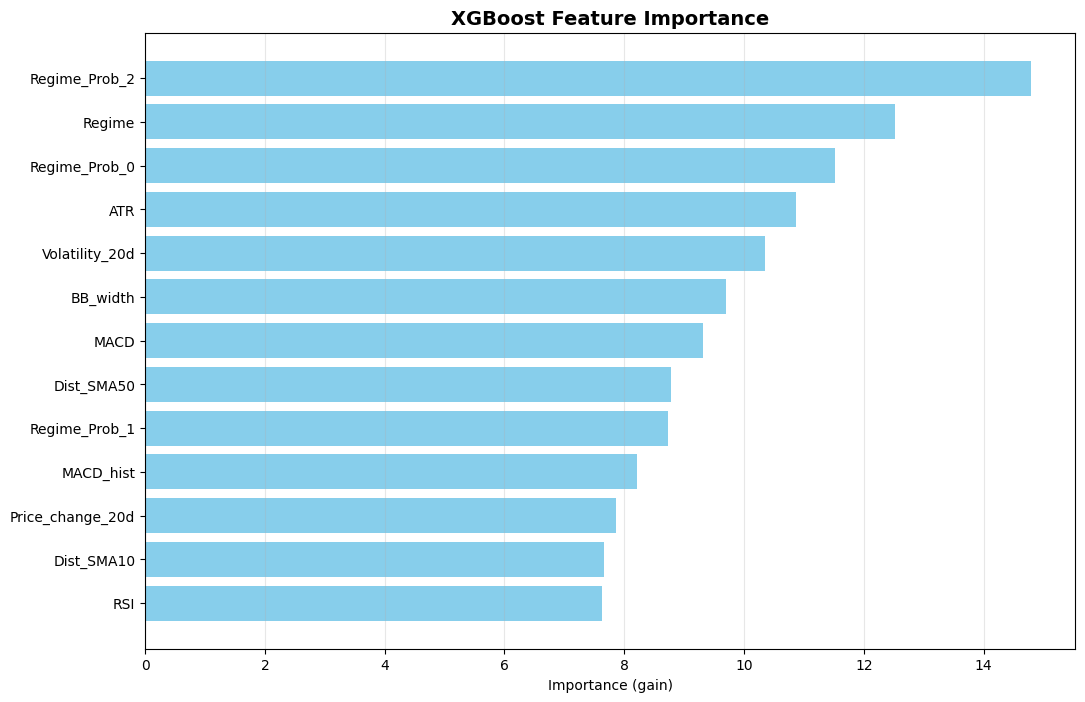


Bảng xếp hạng Feature:
             Feature  Importance
12     Regime_Prob_2   14.788447
9             Regime   12.514576
10     Regime_Prob_0   11.512662
4                ATR   10.875771
5     Volatility_20d   10.351713
3           BB_width    9.693368
1               MACD    9.321144
8         Dist_SMA50    8.778138
11     Regime_Prob_1    8.723697
2          MACD_hist    8.208381
6   Price_change_20d    7.858142
7         Dist_SMA10    7.655800
0                RSI    7.627680


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

print("="*60)
print("BƯỚC 1: ĐÁNH GIÁ TẦM QUAN TRỌNG CỦA CÁC FEATURE")
print("="*60)

if 'model' not in locals():
    print("Training temporary model to check importance...")
    model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

# Lấy Feature Importance
# 'gain': Đóng góp của feature vào việc giảm độ nhiễu (Quan trọng nhất)
# 'weight': Số lần feature được dùng để tách nhánh
importance_type = 'gain' 
feature_importance = model.get_booster().get_score(importance_type=importance_type)

# Chuyển về DataFrame và sắp xếp
imp_df = pd.DataFrame(list(feature_importance.items()), columns=['Feature', 'Importance'])
imp_df = imp_df.sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='skyblue')
plt.xlabel(f'Importance ({importance_type})')
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

print("\nBảng xếp hạng Feature:")
print(imp_df)

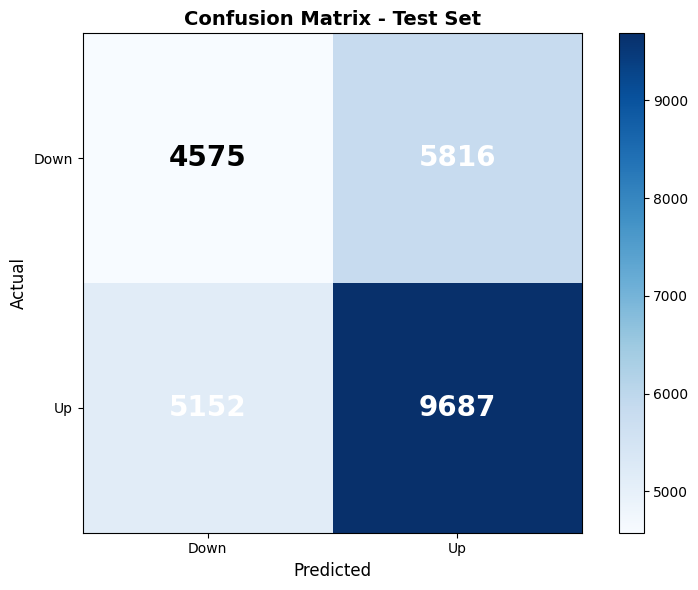


Detailed Metrics:
True Negatives:  4575
False Positives: 5816
False Negatives: 5152
True Positives:  9687

Precision: 0.6248
Recall:    0.6528


In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test_new)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Add labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Down', 'Up'])
ax.set_yticklabels(['Down', 'Up'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                      color="white" if cm[i, j] > cm.max()/2 else "black",
                      fontsize=20, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
print("\nDetailed Metrics:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nPrecision: {tp/(tp+fp):.4f}")
print(f"Recall:    {tp/(tp+fn):.4f}")

In [ ]:
print("="*80)
print("SLIDING WINDOW VALIDATION")
print("="*80)

# 1. Cấu hình cửa sổ thời gian
train_window_years = 3
test_window_months = 6

train_window_days = train_window_years * 252
test_window_days = test_window_months * 21

sw_walks = []
current_pos = train_window_days

# Tạo các cửa sổ cuộn
while current_pos + test_window_days <= len(X_train):
    train_start_idx = current_pos - train_window_days
    train_end_idx = current_pos
    
    test_start_idx = train_end_idx
    test_end_idx = min(test_start_idx + test_window_days, len(X_train))
    
    # Bỏ qua nếu cửa sổ test quá ngắn (< 1 tháng)
    if test_end_idx - test_start_idx < 20:
        break
    
    sw_walks.append({
        'train_start': train_start_idx,
        'train_end': train_end_idx,
        'test_start': test_start_idx,
        'test_end': test_end_idx
    })
    
    current_pos = test_end_idx

print(f"Generated {len(sw_walks)} sliding windows.")
print(f"Train size: {train_window_years} years | Test size: {test_window_months} months\n")

sw_results = []

# Validation Loop
for i, walk in enumerate(sw_walks, 1):
    # Chuẩn bị dữ liệu cho Window này
    X_tr = X_train.iloc[walk['train_start']:walk['train_end']]
    y_tr = y_train.iloc[walk['train_start']:walk['train_end']]
    X_te = X_train.iloc[walk['test_start']:walk['test_end']]
    y_te = y_train.iloc[walk['test_start']:walk['test_end']]
    
    train_dates_range = train_dates.iloc[walk['train_start']:walk['train_end']]
    test_dates_range = train_dates.iloc[walk['test_start']:walk['test_end']]
    
    weights_tr = compute_sample_weight(class_weight='balanced', y=y_tr)
    
    sw_model = xgb.XGBClassifier(
        n_estimators=3000,      
        learning_rate=0.02,     
        max_depth=8,            
        min_child_weight=10,    
        
        gamma=0.2,              
        subsample=0.85,         
        colsample_bytree=0.8,   
        
        reg_alpha=1.0,          
        reg_lambda=1.0,         
        
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        early_stopping_rounds=100
    )
    
    # Training
    sw_model.fit(
        X_tr, y_tr, 
        sample_weight=weights_tr, 
        eval_set=[(X_tr, y_tr), (X_te, y_te)],
        verbose=False
    )
    
    # Tối ưu Threshold (Threshold Moving)
    y_pred_proba = sw_model.predict_proba(X_te)[:, 1]
    
    thresholds = np.arange(0.5, 0.75, 0.005)
    best_acc = 0
    best_thresh = 0.5
    
    for t in thresholds:
        y_temp = (y_pred_proba > t).astype(int)
        acc_t = accuracy_score(y_te, y_temp)
        if acc_t > best_acc:
            best_acc = acc_t
            best_thresh = t
            
    # Dự báo cuối cùng với ngưỡng tối ưu của window 
    y_pred = (y_pred_proba > best_thresh).astype(int)
    
    # Tính Metrics
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    
    try:
        down_recall = recall_score(y_te, y_pred, pos_label=0, zero_division=0)
    except:
        down_recall = 0.0

    result = {
        'walk': i,
        'test_period': f"{test_dates_range.min().date()} -> {test_dates_range.max().date()}",
        'accuracy': acc,
        'best_threshold': best_thresh, # Lưu lại ngưỡng tối ưu 
        'precision': prec,
        'down_recall': down_recall,
        'f1': f1
    }
    sw_results.append(result)
    
    # In tiến độ
    print(f"Win {i}: {result['test_period']} | Acc: {acc:.4f} (Thresh: {best_thresh:.2f}) | Down Recall: {down_recall:.4f}")

sw_df = pd.DataFrame(sw_results)

# Tổng kết
print("\n" + "="*80)
print("SLIDING WINDOW SUMMARY (HIGH PERFORMANCE STRATEGY)")
print("="*80)
print(f"Total Windows:    {len(sw_df)}")
print(f"Avg Accuracy:     {sw_df['accuracy'].mean():.4f} ± {sw_df['accuracy'].std():.4f}")
print(f"Avg Down Recall:  {sw_df['down_recall'].mean():.4f} ± {sw_df['down_recall'].std():.4f}")
print(f"Avg Threshold:    {sw_df['best_threshold'].mean():.4f}")
print("-" * 80)
print(f"Min Accuracy:     {sw_df['accuracy'].min():.4f} (Vào giai đoạn: {sw_df.loc[sw_df['accuracy'].idxmin(), 'test_period']})")
print(f"Max Accuracy:     {sw_df['accuracy'].max():.4f} (Vào giai đoạn: {sw_df.loc[sw_df['accuracy'].idxmax(), 'test_period']})")
print("="*80)

SLIDING WINDOW VALIDATION
Generated 362 sliding windows.
Train size: 3 years | Test size: 6 months

Win 1: 1996-04-09 -> 1996-10-04 | Acc: 0.5476 (Thresh: 0.50) | Down Recall: 0.1778
Win 2: 1996-10-07 -> 1997-04-07 | Acc: 0.3968 (Thresh: 0.51) | Down Recall: 1.0000
Win 3: 1997-04-08 -> 1997-10-03 | Acc: 0.3333 (Thresh: 0.50) | Down Recall: 0.8000
Win 4: 1997-10-06 -> 1998-04-06 | Acc: 0.5476 (Thresh: 0.72) | Down Recall: 0.7879
Win 5: 1998-04-07 -> 1998-10-05 | Acc: 0.6111 (Thresh: 0.51) | Down Recall: 0.6462
Win 6: 1998-10-06 -> 1999-04-07 | Acc: 0.7063 (Thresh: 0.51) | Down Recall: 0.3871
Win 7: 1999-04-08 -> 1999-10-05 | Acc: 0.6190 (Thresh: 0.50) | Down Recall: 0.4262
Win 8: 1999-10-06 -> 2000-04-04 | Acc: 0.6032 (Thresh: 0.52) | Down Recall: 0.7037
Win 9: 2000-04-05 -> 2000-10-03 | Acc: 0.7222 (Thresh: 0.61) | Down Recall: 0.8873
Win 10: 2000-10-04 -> 2001-04-04 | Acc: 0.6349 (Thresh: 0.54) | Down Recall: 0.8205
Win 11: 2001-04-05 -> 2001-10-09 | Acc: 0.6270 (Thresh: 0.60) | Down 